In [8]:
!pip install shap

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv("processed_telco.csv")

In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

In [12]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(1409, 33, 2)


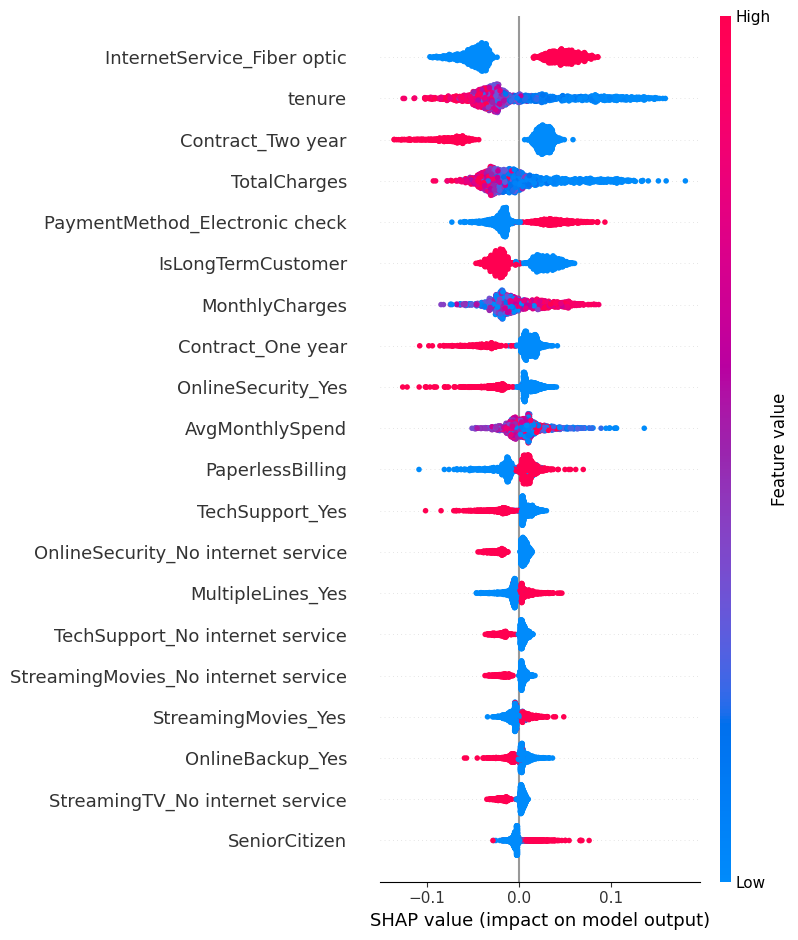

In [13]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

SHAP analysis revealed that InternetService_Fiber optic, tenure, Contract type, TotalCharges, and Payment Method were the most influential features affecting customer churn. Customers with shorter tenure, fiber optic internet service, and electronic check payment methods showed a higher likelihood of churn. Long-term contracts and higher tenure generally reduced churn probability.

In [14]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,TotalCharges,0.149632
30,AvgMonthlySpend,0.130385
7,MonthlyCharges,0.129818
4,tenure,0.128218
31,ServiceCount,0.033841
11,InternetService_Fiber optic,0.033448
28,PaymentMethod_Electronic check,0.032538
26,Contract_Two year,0.030239
32,IsLongTermCustomer,0.028173
6,PaperlessBilling,0.023478


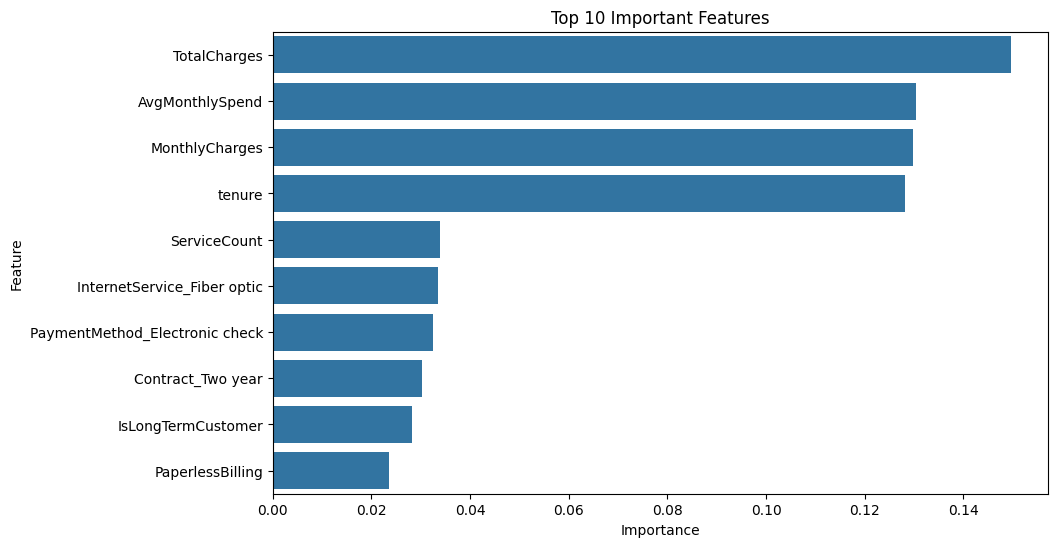

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

In [16]:
df.groupby("gender")["Churn"].mean()

,Churn
gender,
0,0.269209
1,0.261603


In [17]:
df.groupby("SeniorCitizen")["Churn"].mean()

,Churn
SeniorCitizen,
0,0.236062
1,0.416813


Fairness Evaluation

The churn rates for both gender groups were very similar (26.9% and 26.2%). This indicates that the model does not exhibit significant gender-based bias and treats both groups fairly.

Business Recommendations

1. Focus retention efforts on customers with short tenure.
2. Offer discounts or loyalty rewards to customers likely to churn.
3. Improve support services for high-risk customer groups.
4. Encourage long-term contracts to reduce churn.
5. Monitor customers with high monthly charges and low engagement.

Conclusion

The project successfully analyzed customer churn using machine learning techniques. Logistic Regression was selected as the best classification model due to its high recall and ROC-AUC score. Linear Regression achieved the best performance for predicting monthly charges. SHAP analysis and feature importance identified the key factors influencing churn, enabling actionable business recommendations for customer retention.